### Import the Libraries

In [ ]:
# Diabetes Prediction Using Machine Learning

## Project Overview

# This project develops and evaluates multiple machine learning models for diabetes prediction using health-related 
# indicators. The workflow includes data exploration, preprocessing, model development, hyperparameter optimization,
# and explainable AI using SHAP to identify the most influential predictors.

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns


# Visualization
import matplotlib.pyplot as plt
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Phase:1 Load and understand the Dataset

In [152]:
df = pd.read_csv(r"D:\Mig\project 1/diabetes_binary_health_indicators_BRFSS2015.csv")

In [6]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [8]:
df.shape

(253680, 22)

In [10]:
df.columns.tolist()

['Diabetes_binary',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [13]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [17]:
df.duplicated().sum()

## we can not remove duplicates as the parameters can be the same for two persons, so we keep them

24206

In [18]:
df[df.duplicated()]

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1242,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
1563,0.0,0.0,0.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
2700,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
3160,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
3332,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,1.0,1.0,1.0,1.0,33.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,9.0,6.0,6.0
253550,0.0,0.0,0.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,7.0,6.0,8.0
253563,0.0,0.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0
253597,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0


### Target Variable Analysis

In [22]:
df["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

In [23]:
(df["Diabetes_binary"].value_counts(normalize=True) * 100).round(2)

Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64

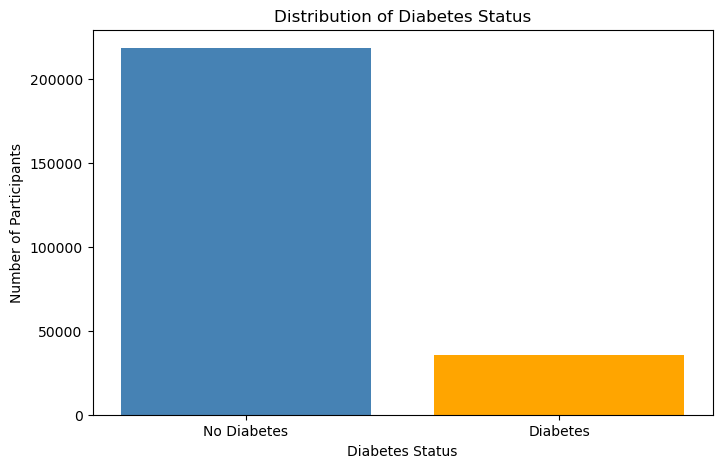

In [44]:
target_counts = df["Diabetes_binary"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    ["No Diabetes", "Diabetes"],
    target_counts.values,
    color=["steelblue", "orange"]
)

plt.xlabel("Diabetes Status")
plt.ylabel("Number of Participants")
plt.title("Distribution of Diabetes Status")

plt.show()

# Phase 2: Exploratory Data Analysis (EDA)

In [50]:
binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits',
    'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'DiffWalk', 'Sex'
]

             ### We create these categories based on data types like dichotoumus, ordinal and continous.

ordinal_features = [
    'Age',
    'Education',
    'Income'
]

continuous_features = [
    'GenHlth',
    'BMI',
    'MentHlth',
    'PhysHlth'
]

target = "Diabetes_binary"

#### Binary_features Analysis

In [31]:
binary_summary = []

for feature in binary_features:

    prevalence = (
        df.groupby(feature)["Diabetes_binary"]
        .mean()
        .mul(100)
    )

    binary_summary.append({
        "Feature": feature,
        "No (%)": round(prevalence.get(0, 0), 2),
        "Yes (%)": round(prevalence.get(1, 0), 2),
        "Difference (%)": round(prevalence.get(1, 0) - prevalence.get(0, 0), 2)
    })

binary_summary = (
    pd.DataFrame(binary_summary)
    .sort_values("Difference (%)", ascending=False)
)

binary_summary

,Feature,No (%),Yes (%),Difference (%)
5,HeartDiseaseorAttack,11.95,32.97,21.02
12,DiffWalk,10.53,30.75,20.21
4,Stroke,13.18,31.75,18.57
0,HighBP,6.04,24.45,18.41
1,HighChol,7.98,22.01,14.03
2,CholCheck,2.54,14.37,11.83
3,Smoker,12.06,16.29,4.24
11,NoDocbcCost,13.60,17.52,3.92
10,AnyHealthcare,11.45,14.06,2.61
13,Sex,12.97,15.16,2.19


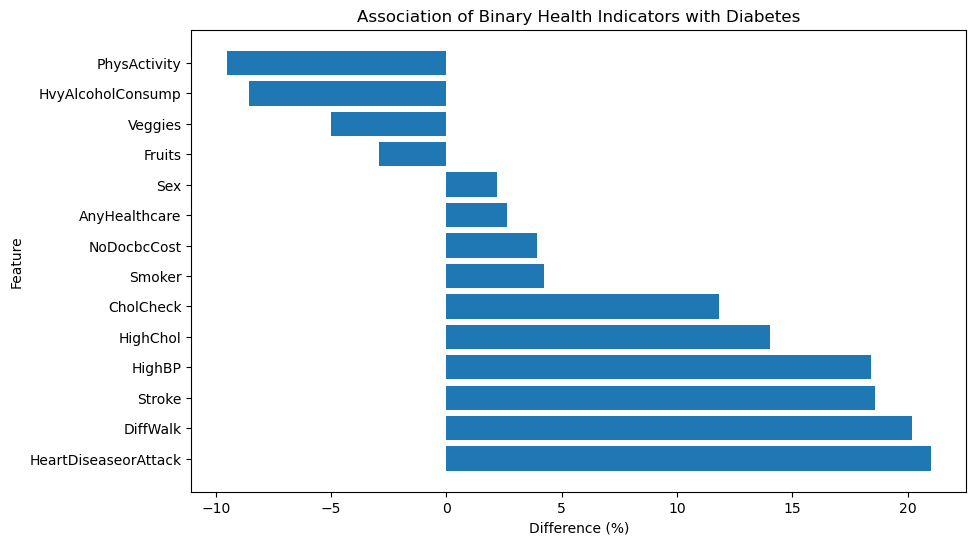

In [54]:
plt.figure(figsize=(10, 6))

plt.barh(
    binary_summary["Feature"],
    binary_summary["Difference (%)"]
)

plt.xlabel("Difference (%)")
plt.ylabel("Feature")
plt.title("Association of Binary Health Indicators with Diabetes")

plt.show()

#### Ordinal_features Analysis

In [35]:
age_labels = {
    1: "18-24",
    2: "25-29",
    3: "30-34",
    4: "35-39",
    5: "40-44",
    6: "45-49",
    7: "50-54",
    8: "55-59",
    9: "60-64",
    10: "65-69",
    11: "70-74",
    12: "75-79",
    13: "80+"
}

age_table = (
    df.groupby("Age")["Diabetes_binary"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

age_table["Age"] = age_table["Age"].map(age_labels)
age_table.rename(columns={
    "Age": "Age Group",
    "Diabetes_binary": "Diabetes Prevalence (%)"
}, inplace=True)

age_table

,Age Group,Diabetes Prevalence (%)
0,18-24,1.37
1,25-29,1.84
2,30-34,2.82
3,35-39,4.53
4,40-44,6.50
5,45-49,8.79
6,50-54,11.74
7,55-59,13.83
8,60-64,17.25
9,65-69,20.37


In [36]:
genhlth_labels = {
    1: "Excellent",
    2: "Very Good",
    3: "Good",
    4: "Fair",
    5: "Poor"
}

genhlth_table = (
    df.groupby("GenHlth")["Diabetes_binary"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

genhlth_table["GenHlth"] = genhlth_table["GenHlth"].map(genhlth_labels)
genhlth_table.rename(columns={
    "GenHlth": "General Health",
    "Diabetes_binary": "Diabetes Prevalence (%)"
}, inplace=True)

genhlth_table

,General Health,Diabetes Prevalence (%)
0,Excellent,2.52
1,Very Good,7.16
2,Good,17.79
3,Fair,31.01
4,Poor,37.89


In [37]:
education_labels = {
    1: "Never attended school",
    2: "Elementary (Grades 1-8)",
    3: "Some High School",
    4: "High School Graduate",
    5: "Some College/Technical School",
    6: "College Graduate"
}

education_table = (
    df.groupby("Education")["Diabetes_binary"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

education_table["Education"] = education_table["Education"].map(education_labels)
education_table.rename(columns={
    "Education": "Education Level",
    "Diabetes_binary": "Diabetes Prevalence (%)"
}, inplace=True)

education_table

,Education Level,Diabetes Prevalence (%)
0,Never attended school,27.01
1,Elementary (Grades 1-8),29.26
2,Some High School,24.22
3,High School Graduate,17.64
4,Some College/Technical School,14.81
5,College Graduate,9.69


In [38]:
income_labels = {
    1: "< $10,000",
    2: "$10,000-$14,999",
    3: "$15,000-$19,999",
    4: "$20,000-$24,999",
    5: "$25,000-$34,999",
    6: "$35,000-$49,999",
    7: "$50,000-$74,999",
    8: "$75,000+"
}

income_table = (
    df.groupby("Income")["Diabetes_binary"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

income_table["Income"] = income_table["Income"].map(income_labels)
income_table.rename(columns={
    "Income": "Income Level",
    "Diabetes_binary": "Diabetes Prevalence (%)"
}, inplace=True)

income_table

,Income Level,Diabetes Prevalence (%)
0,"< $10,000",24.29
1,"$10,000-$14,999",26.19
2,"$15,000-$19,999",22.31
3,"$20,000-$24,999",20.13
4,"$25,000-$34,999",17.40
5,"$35,000-$49,999",14.51
6,"$50,000-$74,999",12.18
7,"$75,000+",7.96


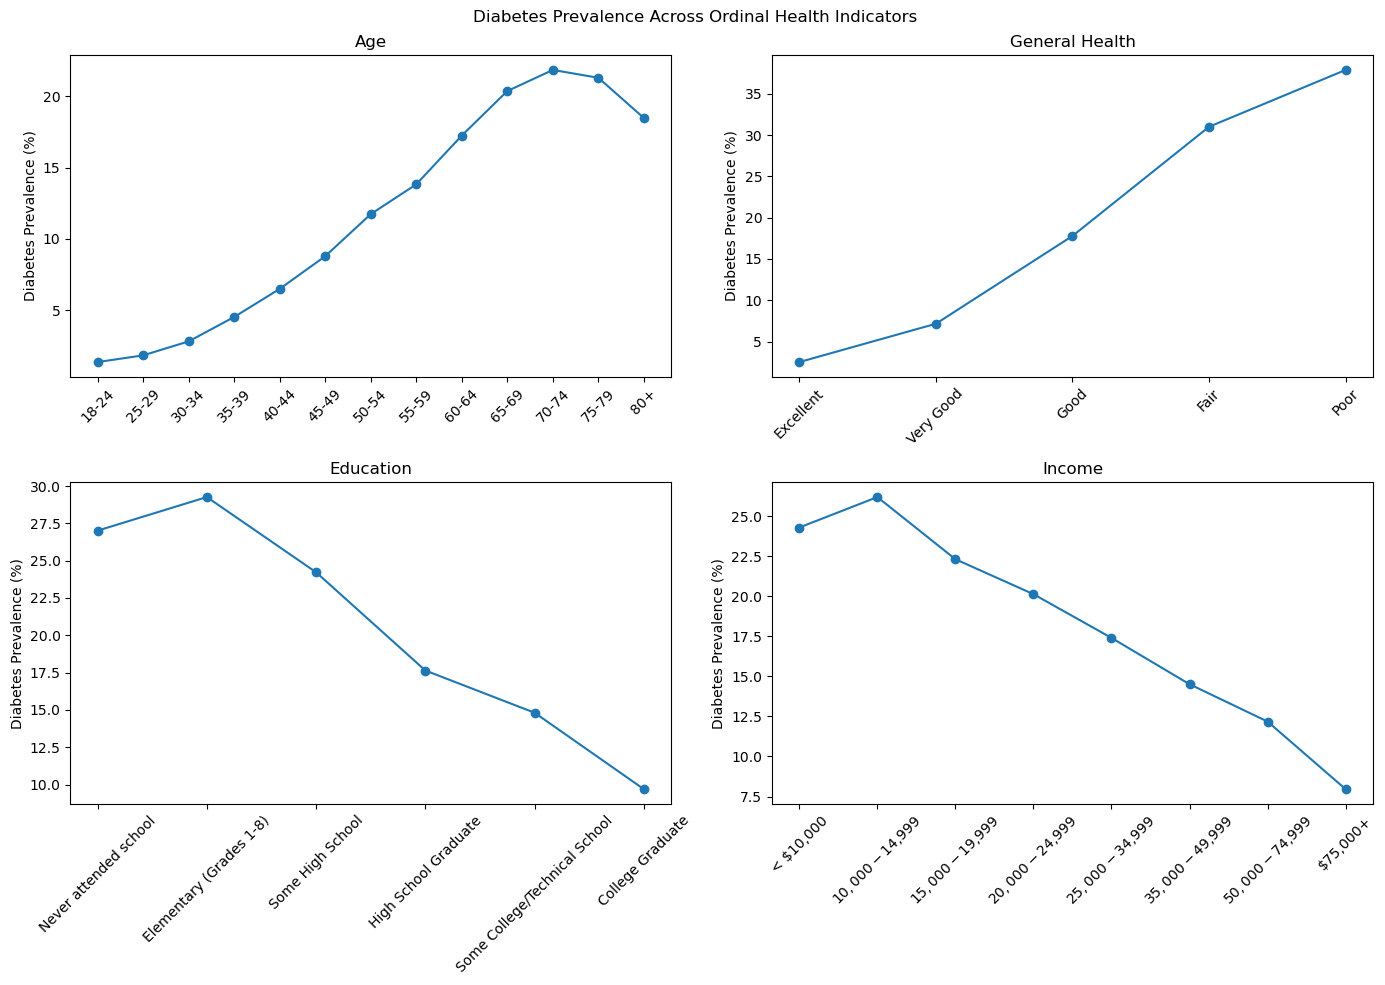

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age
axes[0, 0].plot(
    age_table["Age Group"],
    age_table["Diabetes Prevalence (%)"],
    marker="o"
)
axes[0, 0].set_title("Age")
axes[0, 0].set_ylabel("Diabetes Prevalence (%)")
axes[0, 0].tick_params(axis='x', rotation=45)

# General Health
axes[0, 1].plot(
    genhlth_table["General Health"],
    genhlth_table["Diabetes Prevalence (%)"],
    marker="o"
)
axes[0, 1].set_title("General Health")
axes[0, 1].set_ylabel("Diabetes Prevalence (%)")
axes[0, 1].tick_params(axis='x', rotation=45)

# Education
axes[1, 0].plot(
    education_table["Education Level"],
    education_table["Diabetes Prevalence (%)"],
    marker="o"
)
axes[1, 0].set_title("Education")
axes[1, 0].set_ylabel("Diabetes Prevalence (%)")
axes[1, 0].tick_params(axis='x', rotation=45)

# Income
axes[1, 1].plot(
    income_table["Income Level"],
    income_table["Diabetes Prevalence (%)"],
    marker="o"
)
axes[1, 1].set_title("Income")
axes[1, 1].set_ylabel("Diabetes Prevalence (%)")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle("Diabetes Prevalence Across Ordinal Health Indicators")
plt.tight_layout()
plt.show()

#### Continous_features Analysis

In [48]:
continuous_summary = (
    df[continuous_features]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .T
    .round(2)
)

continuous_summary.columns = [
    "Mean",
    "Median",
    "Standard Deviation",
    "Minimum",
    "Maximum"
]

continuous_summary

,Mean,Median,Standard Deviation,Minimum,Maximum
GenHlth,2.51,2.0,1.07,1.0,5.0
BMI,28.38,27.0,6.61,12.0,98.0
MentHlth,3.18,0.0,7.41,0.0,30.0
PhysHlth,4.24,0.0,8.72,0.0,30.0


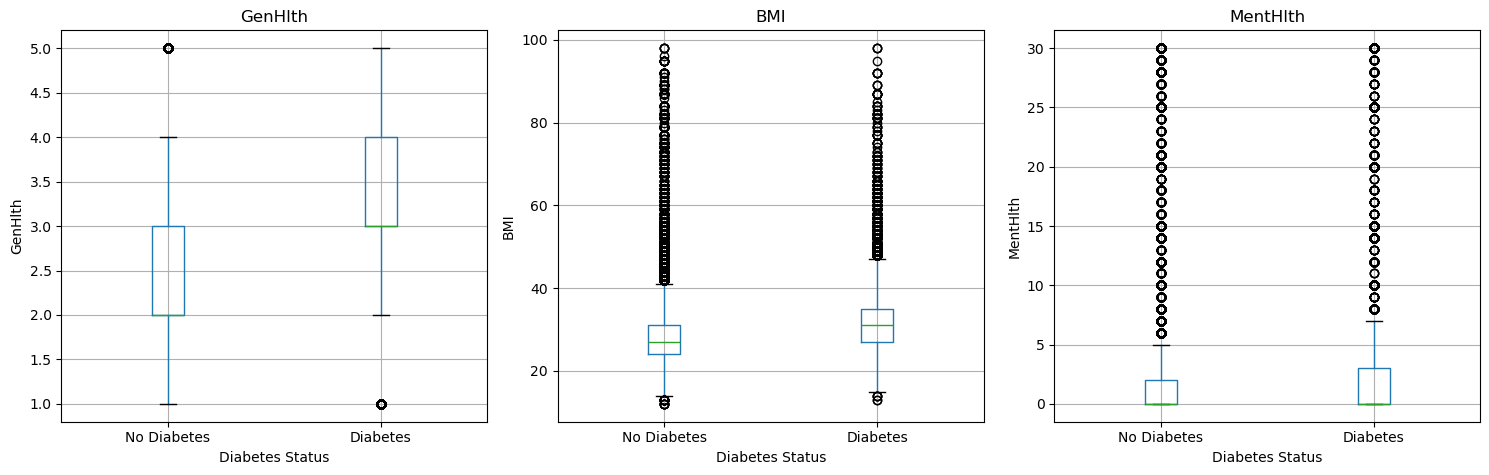

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, continuous_features):
    df.boxplot(
        column=feature,
        by="Diabetes_binary",
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Diabetes Status")
    ax.set_ylabel(feature)
    ax.set_xticklabels(["No Diabetes", "Diabetes"])

plt.suptitle("")
plt.tight_layout()
plt.show()

# Phase 3: Data Preprocessing

In [62]:
X = df.drop(columns="Diabetes_binary")
y = df["Diabetes_binary"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (253680, 21)
Target shape: (253680,)


In [64]:
## Train Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (202944, 21)
Testing set : (50736, 21)

Training target distribution:
Diabetes_binary
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64

Testing target distribution:
Diabetes_binary
0.0    0.860671
1.0    0.139329
Name: proportion, dtype: float64


In [65]:
## check class imbalance 

class_distribution = (
    y_train.value_counts()
    .rename(index={0.0: "No Diabetes", 1.0: "Diabetes"})
    .to_frame(name="Count")
)

class_distribution["Percentage (%)"] = (
    class_distribution["Count"] / class_distribution["Count"].sum() * 100
).round(2)

class_distribution

,Count,Percentage (%)
Diabetes_binary,,
No Diabetes,174667,86.07
Diabetes,28277,13.93


# Phase 4: Machine learning Models

In [127]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   -- ------------------------------------- 1.0/15.6 MB 4.6 MB/s eta 0:00:04
   -------- ------------------------------- 3.4/15.6 MB 8.7 MB/s eta 0:00:02
   -------------------- ------------------- 7.9/15.6 MB 13.1 MB/s eta 0:00:01
   ------------------------------------ --- 14.4/15.6 MB 18.1 MB/s eta 0:00:01
   ------------------------------------ --- 14.4/15.6 MB 18.1 MB/s eta 0:00:01
   ------------------------------------ --- 14.4/15.6 MB 18.1 MB/s eta 0:00:01
   ------------------------------------ --- 14.4/15.6 MB 18.1 MB/s eta 0:00:01
   ------------------------------------ --- 14.4/15.6 MB 18.1 MB/s eta 0:00:01
   ------------------------------------ --- 14.4/15.6 MB 18.1 MB/s eta 0:00:01
   ------------------------------------ --- 14.4/15.6 MB 18.1 MB/s eta 0:00:01
   ------------------------------------ --- 14.4/15.6 MB 18.1 MB/s 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.


In [129]:
## import Ml Libraries 

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
import shap


### Model 1: Logistic regression

In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
log_reg = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [70]:
## Generate predictions

# Predicted class labels
y_pred_log = log_reg.predict(X_test_scaled)

# Predicted probabilities (for ROC-AUC)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

In [71]:
## Evaluate the model

log_reg_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1-Score": f1_score(y_test, y_pred_log),
    "ROC-AUC": roc_auc_score(y_test, y_prob_log)
}

pd.DataFrame([log_reg_results]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7315,0.3107,0.7611,0.4413,0.8196


In [72]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Classification Report:

              precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     43667
         1.0       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736


Confusion Matrix:

[[31734 11933]
 [ 1689  5380]]


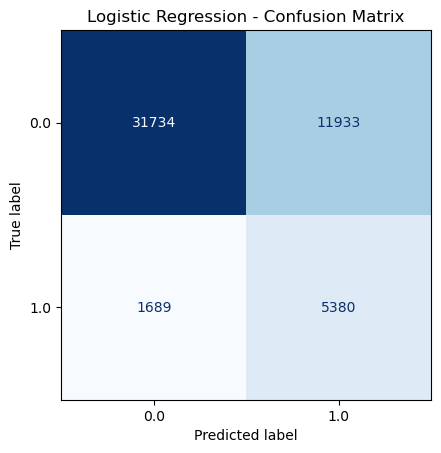

In [110]:
## Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap="Blues",
    colorbar=False
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

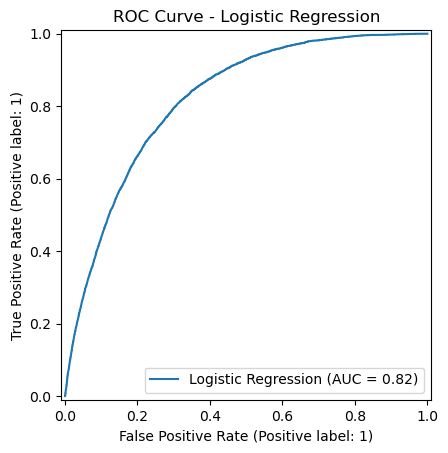

In [114]:
## ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log,
    name="Logistic Regression"
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

### Model 2: Decision Tree

In [73]:
decision_tree = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [77]:
## Make Predictions
y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [78]:
### Evaluate
dt_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-Score": f1_score(y_test, y_pred_dt),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
}

pd.DataFrame([dt_results]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.7977,0.2836,0.2961,0.2897,0.5875


In [79]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Classification Report:

              precision    recall  f1-score   support

         0.0       0.89      0.88      0.88     43667
         1.0       0.28      0.30      0.29      7069

    accuracy                           0.80     50736
   macro avg       0.58      0.59      0.59     50736
weighted avg       0.80      0.80      0.80     50736


Confusion Matrix:

[[38380  5287]
 [ 4976  2093]]


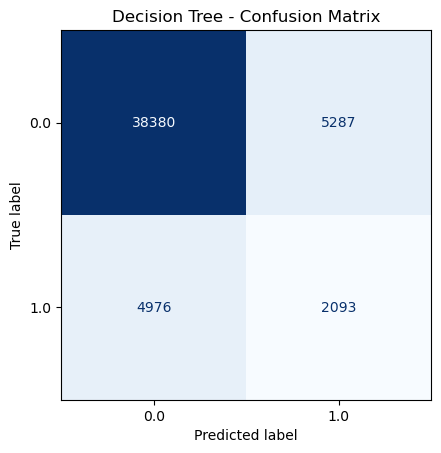

In [115]:
## Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Blues",
    colorbar=False
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

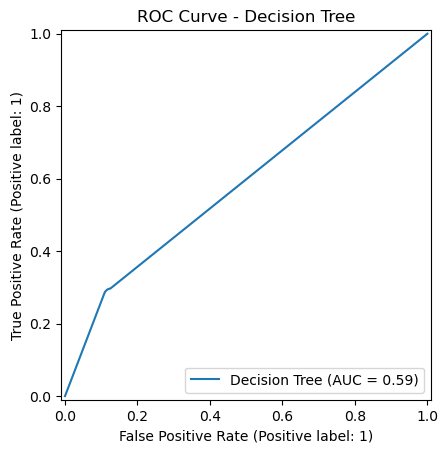

In [116]:
## ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt,
    name="Decision Tree"
)

plt.title("ROC Curve - Decision Tree")
plt.show()

### Model 3: Random Forest

In [80]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [81]:
## Make predictions

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [82]:
## Evaluate the model 

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
}

pd.DataFrame([rf_results]).round(4)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8568,0.4591,0.1546,0.2313,0.7947


In [83]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.46      0.15      0.23      7069

    accuracy                           0.86     50736
   macro avg       0.67      0.56      0.58     50736
weighted avg       0.82      0.86      0.82     50736


Confusion Matrix:

[[42379  1288]
 [ 5976  1093]]


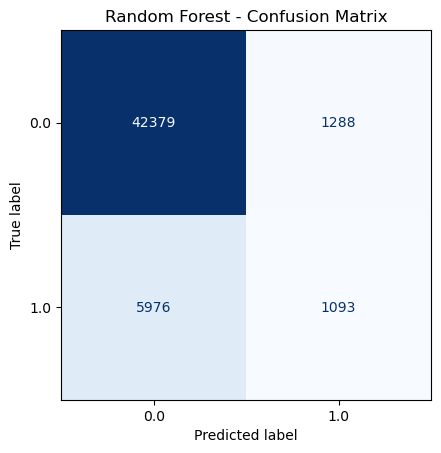

In [117]:
## Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues",
    colorbar=False
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

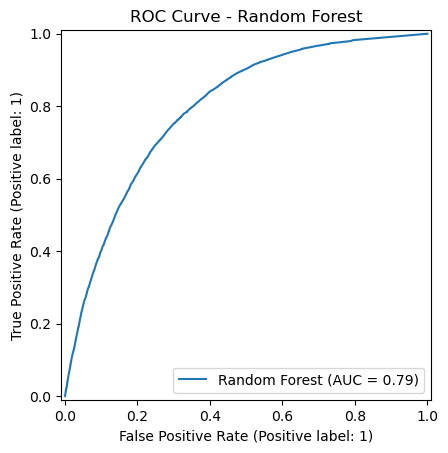

In [118]:
## ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.title("ROC Curve - Random Forest")
plt.show()

### Model 4: XGBoost

In [85]:
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 6.18


In [88]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [89]:
## Make prediction 

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [90]:
## Evaluate model 

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1-Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
}

pd.DataFrame([xgb_results]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7251,0.308,0.7807,0.4417,0.825


In [91]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

Classification Report:

              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82     43667
         1.0       0.31      0.78      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.73      0.77     50736


Confusion Matrix:

[[31268 12399]
 [ 1550  5519]]


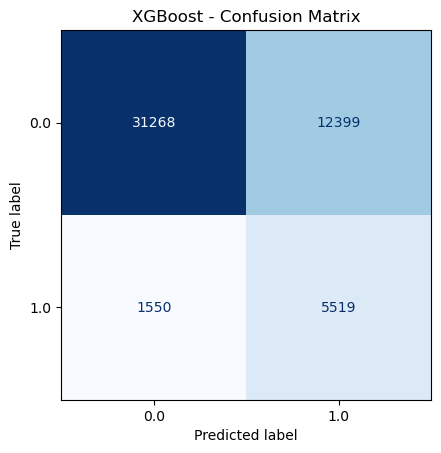

In [119]:
## Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Blues",
    colorbar=False
)

plt.title("XGBoost - Confusion Matrix")
plt.show()

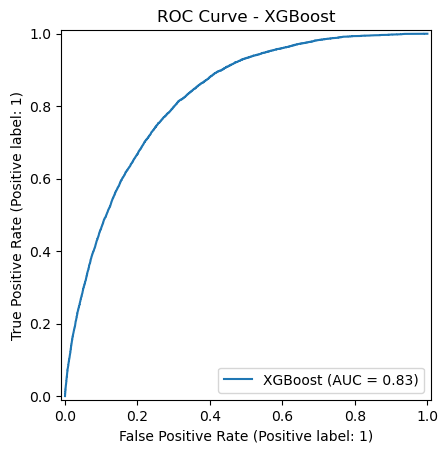

In [120]:
## ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC Curve - XGBoost")
plt.show()

In [92]:
pd.DataFrame([log_reg_results, dt_results, rf_results, xgb_results]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7315,0.3107,0.7611,0.4413,0.8196
1,Decision Tree,0.7977,0.2836,0.2961,0.2897,0.5875
2,Random Forest,0.8568,0.4591,0.1546,0.2313,0.7947
3,XGBoost,0.7251,0.3080,0.7807,0.4417,0.8250


# Phase 5: Hyperparameter Optimization

In [96]:
## Define Hyperparameter Search Space

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

In [97]:
## Perform Randomized Search

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=200, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [98]:
## View the Best Hyperparameters

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC Score:")
print(round(random_search.best_score_, 4))

Best Parameters:
{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

Best ROC-AUC Score:
0.8312


### Final Optimized XGBoost Model

In [100]:
## Train the Optimized XGBoost Model

best_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [101]:
## Generate Predictions

y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

In [102]:
## Evaluate the Optimized Model

best_xgb_results = {
    "Model": "Optimized XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall": recall_score(y_test, y_pred_best),
    "F1-Score": f1_score(y_test, y_pred_best),
    "ROC-AUC": roc_auc_score(y_test, y_prob_best)
}

pd.DataFrame([best_xgb_results]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Optimized XGBoost,0.7205,0.3061,0.7945,0.442,0.8273


In [103]:
## Classification Report and Confusion Matrix

print("Classification Report:\n")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_best))

Classification Report:

              precision    recall  f1-score   support

         0.0       0.96      0.71      0.81     43667
         1.0       0.31      0.79      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.72      0.76     50736


Confusion Matrix:

[[30938 12729]
 [ 1453  5616]]


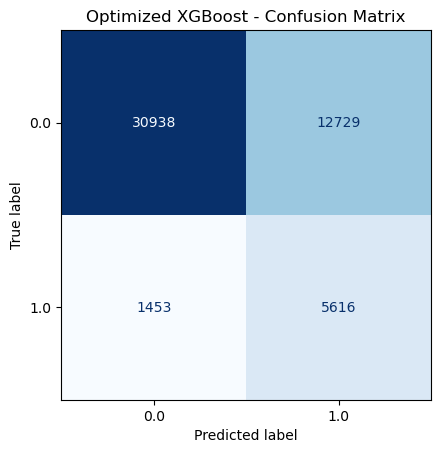

In [121]:
## Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Blues",
    colorbar=False
)

plt.title("Optimized XGBoost - Confusion Matrix")
plt.show()

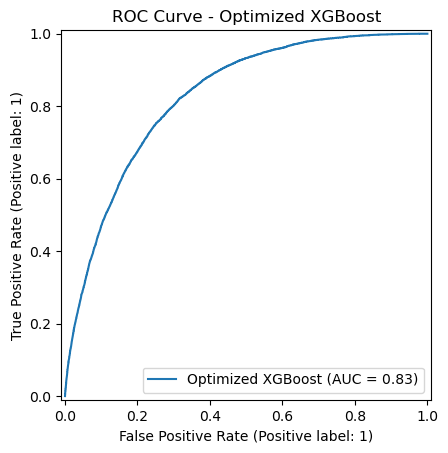

In [122]:
## ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_best,
    name="Optimized XGBoost"
)

plt.title("ROC Curve - Optimized XGBoost")
plt.show()

# Phase 6: Model Explainability

In [123]:
## Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,HighBP,0.540948
13,GenHlth,0.108929
1,HighChol,0.089088
16,DiffWalk,0.044432
6,HeartDiseaseorAttack,0.041930
18,Age,0.037787
3,BMI,0.034140
10,HvyAlcoholConsump,0.021427
2,CholCheck,0.018909
20,Income,0.014388


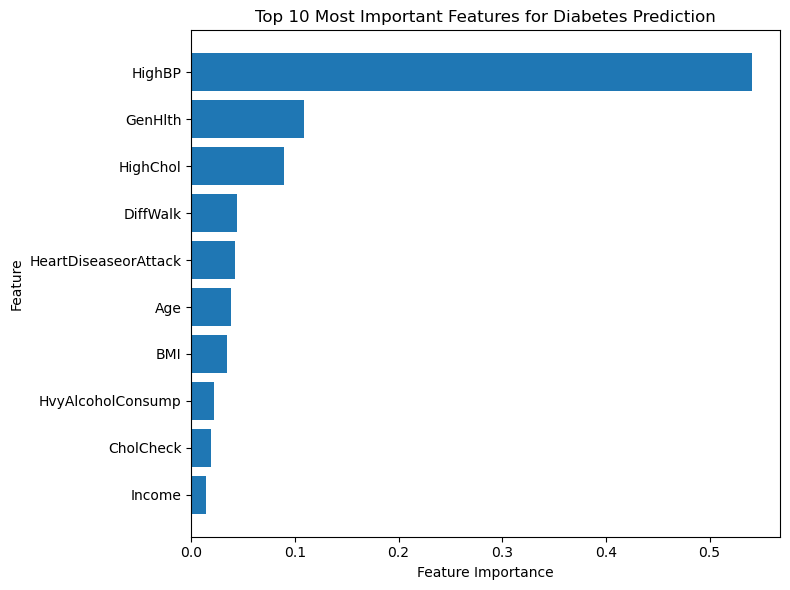

In [124]:
## Top 10 Most Important Features

top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features for Diabetes Prediction")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### SHAP explainability 

In [131]:
# Initialize JavaScript for Jupyter Notebook
shap.initjs()

## Create SHAP Explainer

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)

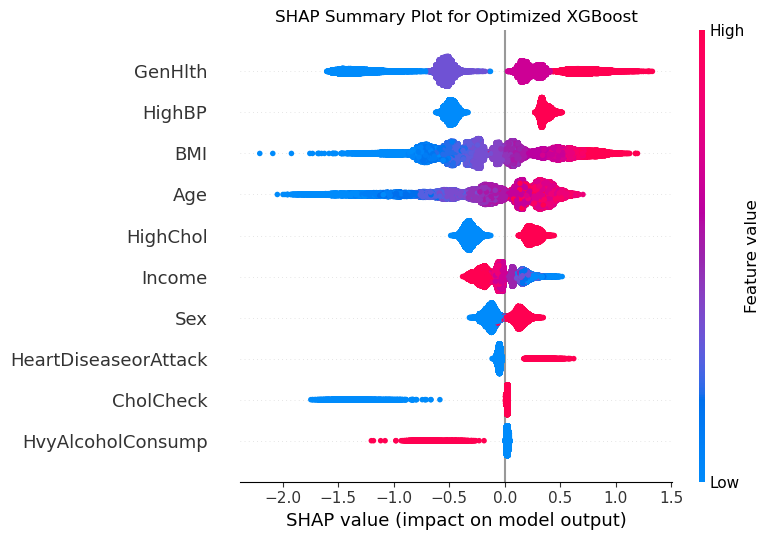

In [133]:
## SHAP Summary Plot (Beeswarm)

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    max_display=10,
    show=False
)

plt.title("SHAP Summary Plot for Optimized XGBoost")
plt.tight_layout()
plt.show()

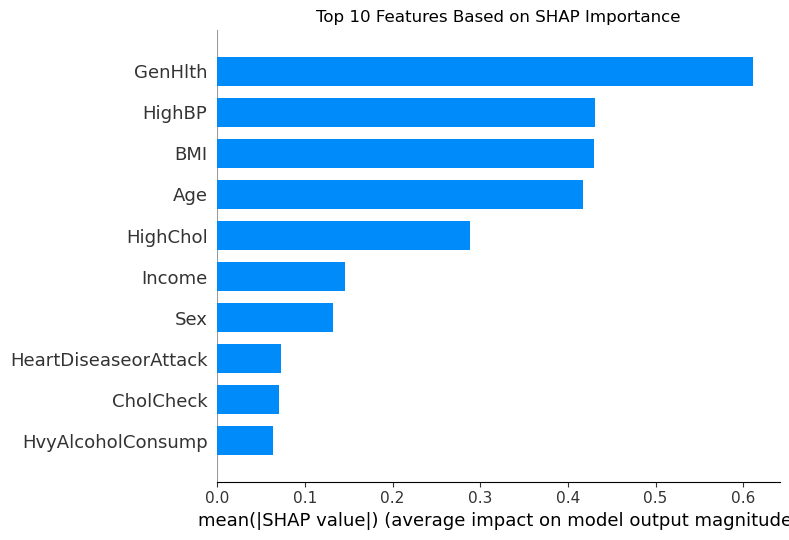

In [151]:
## SHAP Feature Importance (Bar Plot)

plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=10,
    show=False
)

plt.title("Top 10 Features Based on SHAP Importance")
plt.tight_layout()
plt.show()

### Final Model Comparison

In [137]:
## Combine All Model Results

comparison_df = pd.DataFrame([
    log_reg_results,
    dt_results,
    rf_results,
    xgb_results,
    best_xgb_results
]).round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7315,0.3107,0.7611,0.4413,0.8196
1,Decision Tree,0.7977,0.2836,0.2961,0.2897,0.5875
2,Random Forest,0.8568,0.4591,0.1546,0.2313,0.7947
3,XGBoost,0.7251,0.3080,0.7807,0.4417,0.8250
4,Optimized XGBoost,0.7205,0.3061,0.7945,0.4420,0.8273


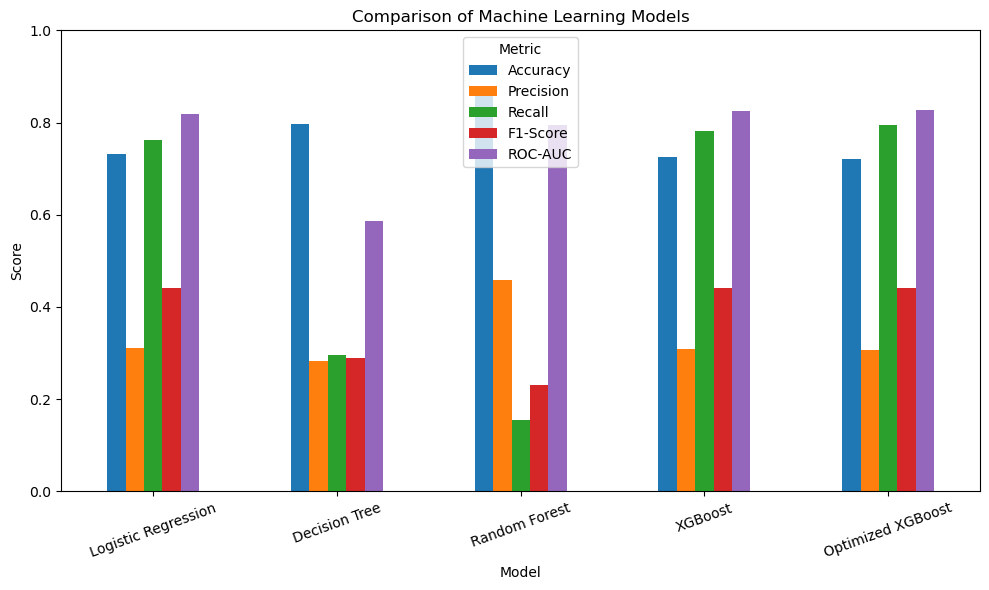

In [141]:
## Compare Evaluation Metrics Across Models

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

comparison_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0,1)

plt.xticks(rotation=20)

plt.legend(title="Metric")

plt.tight_layout()

plt.show()

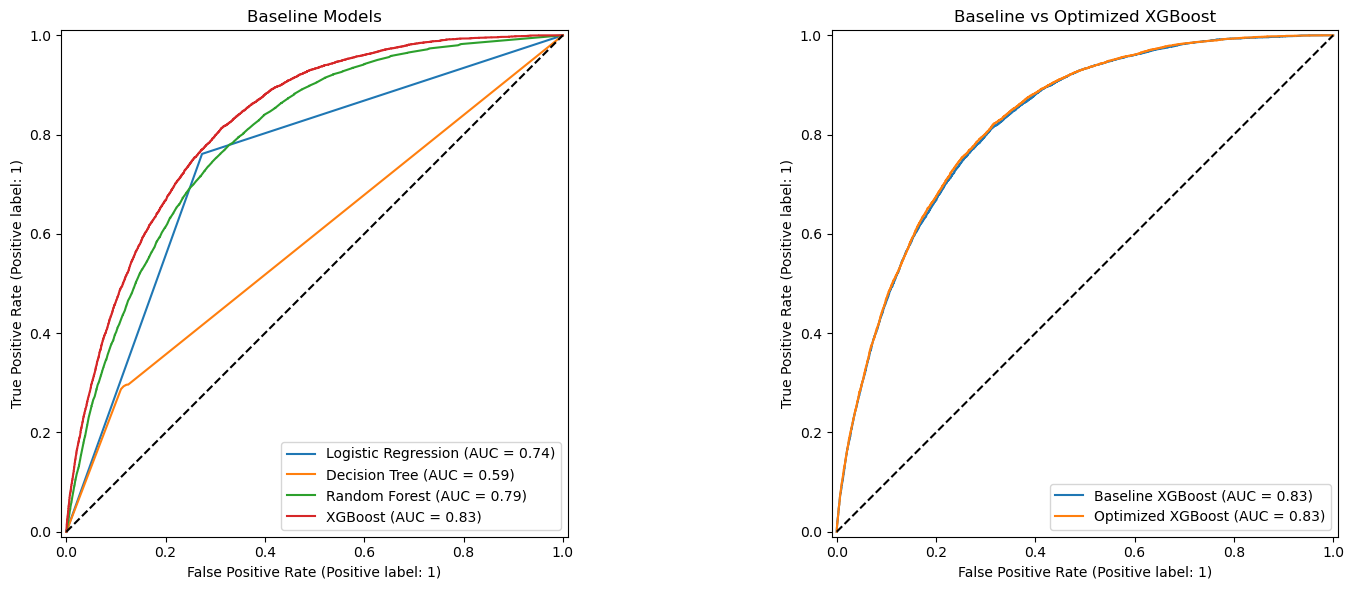

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_log,
    name="Logistic Regression",
    ax=axes[0]
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt,
    name="Decision Tree",
    ax=axes[0]
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest",
    ax=axes[0]
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost",
    ax=axes[0]
)

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("Baseline Models")

# Right Plot: XGBoost Comparison

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="Baseline XGBoost",
    ax=axes[1]
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_best,
    name="Optimized XGBoost",
    ax=axes[1]
)

axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("Baseline vs Optimized XGBoost")

plt.tight_layout()
plt.show()